In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import shap

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
RANDOM_STATE = 42


In [3]:
# 1. ĐỌC VÀ LÀM SẠCH DỮ LIỆU
# -----------------------------------------------------------------
X_train = pd.read_csv("X_train.csv")
X_valid = pd.read_csv("X_valid.csv")
X_test = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv").squeeze("columns")
y_valid = pd.read_csv("y_valid.csv").squeeze("columns")
y_test = pd.read_csv("y_test.csv").squeeze("columns")

w_train = pd.read_csv("w_train.csv").squeeze("columns")

def clean_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()
    if bool_cols:
        df[bool_cols] = df[bool_cols].astype(int)

    non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric_cols:
        print(f"Drop non-numeric columns: {len(non_numeric_cols)} cột")
        print(non_numeric_cols[:10])
        df = df.drop(columns=non_numeric_cols)

    df = df.replace([np.inf, -np.inf], np.nan)
    return df

X_train = clean_features(X_train)
X_valid = clean_features(X_valid)
X_test = clean_features(X_test)

# Đồng bộ cột giữa train / valid / test
X_valid = X_valid.reindex(columns=X_train.columns, fill_value=np.nan)
X_test = X_test.reindex(columns=X_train.columns, fill_value=np.nan)

# Đảm bảo y / weight là 1 chiều
y_train = pd.Series(y_train).astype(int)
y_valid = pd.Series(y_valid).astype(int)
y_test = pd.Series(y_test).astype(int)
w_train = pd.Series(w_train).astype(float)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test :", X_test.shape)
print("y_train positive rate:", y_train.mean())
print("y_valid positive rate:", y_valid.mean())
print("y_test  positive rate:", y_test.mean())
print("Số feature:", X_train.shape[1])
X_train.head()


X_train: (4732, 71)
X_valid: (191, 71)
X_test : (184, 71)
y_train positive rate: 0.12003381234150465
y_valid positive rate: 0.13612565445026178
y_test  positive rate: 0.10326086956521739
Số feature: 71


,txn_count,total_spent,avg_txn,median_txn,max_txn,min_txn,txn_std,merchant_diversity,merchant_count,city_diversity,state_diversity,active_days,insufficient_funds_count,error_count,overnight_count,weekend_count,high_risk_count,chip_count,swipe_count,online_count,observed_span_days,txn_frequency,spending_velocity,spending_volatility,max_to_avg_ratio,insufficient_funds_ratio,declined_ratio,night_ratio,weekend_ratio,high_risk_ratio,chip_ratio,swipe_ratio,online_ratio,merchant_per_txn_ratio,merchant_entropy,avg_monthly_spent,std_monthly_spent,avg_monthly_txn,std_monthly_txn,active_months,monthly_spend_trend,avg_txn_gap_days,std_txn_gap_days,recency_days,total_credit_limit,avg_credit_limit,card_count,debit_card_count,credit_card_count,chip_card_count,avg_cards_issued,current_age,retirement_age,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,debt_to_income,age_to_retirement,spend_to_limit_ratio,spend_to_income_ratio,avg_txn_to_income_ratio,txn_per_card,spent_per_card,spend_last_60,txn_last_60,spend_last_120,txn_last_120,spending_acceleration_60_120,txn_acceleration_60_120
0,106,4941.61,46.618962,43.35,166.00,-97.0,43.747354,24,47,13,6,80,1,1,6,33,3,93,0,13,177,0.598870,27.918701,0.938403,3.560783,0.009434,0.009434,0.056604,0.311321,0.028302,0.877358,0.000000,0.122642,0.443396,2.762522,823.601667,256.752570,17.666667,3.723797,6,69.370571,1.238095,1.638032,0,105656.0,26414.000000,4,3,1,4,1.75,33,69,29237.0,59613.0,36199.0,763,4,0.607233,36,0.046771,0.082895,0.000782,26.500000,1235.402500,1723.64,38.0,3839.56,78.0,0.448916,0.487179
1,85,2189.46,25.758353,23.05,126.72,-88.0,34.092134,22,32,4,3,70,0,0,0,22,1,63,17,5,175,0.485714,12.511200,1.323537,4.919569,0.000000,0.000000,0.000000,0.258824,0.011765,0.741176,0.200000,0.058824,0.376471,2.793386,364.910000,123.393768,14.166667,2.857738,6,-39.218857,1.583333,2.157689,2,50361.0,10072.200000,5,3,2,4,1.40,48,64,13461.0,27447.0,80850.0,673,5,2.945677,16,0.043475,0.079770,0.000938,17.000000,437.892000,457.04,24.0,1322.28,58.0,0.345645,0.413793
2,127,4333.61,34.122913,28.55,754.72,-302.0,90.409956,23,41,13,7,93,0,2,3,31,1,107,18,2,179,0.709497,24.210112,2.649538,22.117689,0.000000,0.015748,0.023622,0.244094,0.007874,0.842520,0.141732,0.015748,0.322835,2.566823,722.268333,487.146987,21.166667,4.708149,6,-171.474571,0.992063,1.359388,1,136202.0,27240.400000,5,4,1,5,1.60,54,72,37485.0,76431.0,115362.0,716,5,1.509361,18,0.031818,0.056700,0.000446,25.400000,866.722000,631.94,36.0,2196.16,75.0,0.287748,0.480000
3,85,5674.16,66.754824,46.27,460.98,-258.0,87.793774,21,32,15,9,68,0,1,5,17,2,79,3,3,176,0.482955,32.239545,1.315167,6.905568,0.000000,0.011765,0.058824,0.200000,0.023529,0.929412,0.035294,0.035294,0.376471,2.322077,945.693333,194.213594,14.166667,2.401388,6,-79.902857,1.666667,1.890581,1,120950.0,20158.333333,6,3,3,6,1.50,39,67,33175.0,67643.0,0.0,714,6,0.000000,28,0.046913,0.083884,0.000987,14.166667,945.693333,1596.74,28.0,3187.20,58.0,0.500985,0.482759
4,55,2279.89,41.452545,24.20,243.25,-307.0,77.395323,23,29,14,4,43,0,0,0,23,0,34,15,6,167,0.329341,13.652036,1.867083,5.868156,0.000000,0.000000,0.000000,0.418182,0.000000,0.618182,0.272727,0.109091,0.527273,2.742398,379.981667,223.508161,9.166667,4.445972,6,-88.744857,2.611111,2.955115,9,24593.0,6148.250000,4,2,2,3,1.50,52,61,15879.0,32378.0,65919.0,588,4,2.035919,9,0.092705,0.070415,0.001280,13.750000,569.972500,326.89,10.0,1183.20,34.0,0.276276,0.294118


In [4]:
# 2. HÀM DÙNG CHUNG
# -----------------------------------------------------------------
def find_best_threshold_f1(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    if len(thresholds) == 0:
        return 0.5, float(np.nanmax(f1_scores))

    valid_f1 = f1_scores[:-1] if len(f1_scores) == len(thresholds) + 1 else f1_scores
    best_idx = int(np.nanargmax(valid_f1))
    best_threshold = float(thresholds[min(best_idx, len(thresholds) - 1)])
    best_f1 = float(valid_f1[best_idx])
    return best_threshold, best_f1


def find_best_threshold_cost(y_true, y_prob, cost_fp=1, cost_fn=10):
    thresholds = np.linspace(0.01, 0.99, 99)

    best_threshold = 0.5
    best_cost = np.inf
    best_cm = None

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        total_cost = fp * cost_fp + fn * cost_fn

        if total_cost < best_cost:
            best_cost = total_cost
            best_threshold = float(t)
            best_cm = (tn, fp, fn, tp)

    return best_threshold, float(best_cost), best_cm


def evaluate_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics = {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }
    return metrics, y_pred


def summarize_model(name, y_true, y_prob, cost_fp=1, cost_fn=10):
    roc_auc = roc_auc_score(y_true, y_prob)

    metrics_05, pred_05 = evaluate_at_threshold(y_true, y_prob, 0.5)

    th_f1, _ = find_best_threshold_f1(y_true, y_prob)
    metrics_f1, pred_f1 = evaluate_at_threshold(y_true, y_prob, th_f1)

    th_cost, best_cost, _ = find_best_threshold_cost(y_true, y_prob, cost_fp=cost_fp, cost_fn=cost_fn)
    metrics_cost, pred_cost = evaluate_at_threshold(y_true, y_prob, th_cost)
    metrics_cost["business_cost"] = best_cost

    summary = {
        "model": name,
        "roc_auc": roc_auc,
        "f1_at_0.5": metrics_05["f1"],
        "recall_at_0.5": metrics_05["recall"],
        "precision_at_0.5": metrics_05["precision"],
        "threshold_f1": th_f1,
        "f1_best": metrics_f1["f1"],
        "threshold_cost": th_cost,
        "business_cost_best": best_cost,
        "recall_at_cost_threshold": metrics_cost["recall"],
        "precision_at_cost_threshold": metrics_cost["precision"],
        "fn_at_cost_threshold": metrics_cost["fn"],
        "fp_at_cost_threshold": metrics_cost["fp"],
    }

    result_pack = {
        "0.5": {"metrics": metrics_05, "pred": pred_05},
        "best_f1": {"metrics": metrics_f1, "pred": pred_f1},
        "best_cost": {"metrics": metrics_cost, "pred": pred_cost},
    }

    return summary, result_pack


def print_detailed_result(model_name, y_true, result_pack):
    for mode, pack in result_pack.items():
        m = pack["metrics"]
        print("=" * 100)
        print(f"{model_name.upper()} | mode = {mode}")
        print(f"Threshold : {m['threshold']:.4f}")
        print(f"ROC-AUC   : {m['roc_auc']:.4f}")
        print(f"Accuracy  : {m['accuracy']:.4f}")
        print(f"Precision : {m['precision']:.4f}")
        print(f"Recall    : {m['recall']:.4f}")
        print(f"F1-score  : {m['f1']:.4f}")
        print("Confusion Matrix:")
        print(np.array([[m['tn'], m['fp']], [m['fn'], m['tp']]]))
        print(classification_report(y_true, pack["pred"], zero_division=0))


def build_threshold_table(y_true, y_prob):
    rows = []
    for t in np.linspace(0.01, 0.99, 99):
        m, _ = evaluate_at_threshold(y_true, y_prob, t)
        rows.append({
            "threshold": t,
            "precision": m["precision"],
            "recall": m["recall"],
            "f1": m["f1"],
            "fp": m["fp"],
            "fn": m["fn"],
        })
    return pd.DataFrame(rows)


## Business cost

Trong bài toán thẻ tín dụng:
- **False Positive (FP)**: từ chối khách hàng tốt → mất doanh thu/phí
- **False Negative (FN)**: duyệt khách hàng rủi ro → mất tiền nợ xấu

In [5]:
# 3. BUSINESS COST GIẢ ĐỊNH

cost_fp = 1
cost_fn = 10

print(f"Giả định cost_fp = {cost_fp}, cost_fn = {cost_fn}")
print("=> False Negative đang bị phạt nặng hơn False Positive")


Giả định cost_fp = 1, cost_fn = 10
=> False Negative đang bị phạt nặng hơn False Positive


In [6]:
# 4. LOGISTIC REGRESSION
# -----------------------------------------------------------------
pipeline_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=3000,
        solver="liblinear",
        class_weight="balanced"
    ))
])

param_dist_lr = {
    "clf__C": np.logspace(-3, 2, 12),
    "clf__penalty": ["l1", "l2"]
}

print("Logistic Regression...")
random_search_lr = RandomizedSearchCV(
    estimator=pipeline_lr,
    param_distributions=param_dist_lr,
    n_iter=12,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search_lr.fit(X_train, y_train, clf__sample_weight=w_train)
best_lr_model = random_search_lr.best_estimator_

print("Best params Logistic Regression:")
print(random_search_lr.best_params_)


Logistic Regression...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params Logistic Regression:
{'clf__penalty': 'l1', 'clf__C': np.float64(0.0657933224657568)}


In [7]:
# 5. XGBOOST
# -----------------------------------------------------------------
pos_count = y_train.sum()
neg_count = len(y_train) - pos_count
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0

pipeline_xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight,
        tree_method="hist"
    ))
])

param_dist_xgb = {
    "clf__n_estimators": [100, 200, 300, 500],
    "clf__max_depth": [3, 4, 5, 6, 8],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "clf__min_child_weight": [1, 3, 5],
    "clf__gamma": [0, 0.1, 0.3]
}

print("XGBoost...")
random_search_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train, clf__sample_weight=w_train)
best_xgb_model = random_search_xgb.best_estimator_

print("Best params XGBoost:")
print(random_search_xgb.best_params_)


XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params XGBoost:
{'clf__subsample': 0.8, 'clf__n_estimators': 100, 'clf__min_child_weight': 5, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__gamma': 0.3, 'clf__colsample_bytree': 0.7}


In [8]:
# 6. RANDOM FOREST

pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

param_dist_rf = {
    "clf__n_estimators": [100, 200, 300, 500],
    "clf__max_depth": [5, 8, 10, 15, None],
    "clf__min_samples_split": [2, 5, 10, 20],
    "clf__min_samples_leaf": [1, 2, 5, 10],
    "clf__max_features": ["sqrt", "log2", None]
}

print("Random Forest...")
random_search_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train, clf__sample_weight=w_train)
best_rf_model = random_search_rf.best_estimator_

print("Best params Random Forest:")
print(random_search_rf.best_params_)


Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params Random Forest:
{'clf__n_estimators': 200, 'clf__min_samples_split': 20, 'clf__min_samples_leaf': 10, 'clf__max_features': 'log2', 'clf__max_depth': None}


In [9]:
# 7. DỰ ĐOÁN XÁC SUẤT VÀ ĐÁNH GIÁ TRÊN VALIDATION

lr_valid_prob = best_lr_model.predict_proba(X_valid)[:, 1]
xgb_valid_prob = best_xgb_model.predict_proba(X_valid)[:, 1]
rf_valid_prob = best_rf_model.predict_proba(X_valid)[:, 1]

lr_summary, lr_pack = summarize_model("Logistic Regression", y_valid, lr_valid_prob, cost_fp=cost_fp, cost_fn=cost_fn)
xgb_summary, xgb_pack = summarize_model("XGBoost", y_valid, xgb_valid_prob, cost_fp=cost_fp, cost_fn=cost_fn)
rf_summary, rf_pack = summarize_model("Random Forest", y_valid, rf_valid_prob, cost_fp=cost_fp, cost_fn=cost_fn)

results_df = pd.DataFrame([lr_summary, xgb_summary, rf_summary]).sort_values(
    by=["business_cost_best", "roc_auc"],
    ascending=[True, False]
).reset_index(drop=True)

print("Kết quả trên VALIDATION.")
display(results_df)

Kết quả trên VALIDATION.


,model,roc_auc,f1_at_0.5,recall_at_0.5,precision_at_0.5,threshold_f1,f1_best,threshold_cost,business_cost_best,recall_at_cost_threshold,precision_at_cost_threshold,fn_at_cost_threshold,fp_at_cost_threshold
0,XGBoost,0.855711,0.537313,0.692308,0.439024,0.721263,0.604651,0.38,64.0,0.884615,0.403509,3,34
1,Random Forest,0.865035,0.553191,0.500000,0.619048,0.604878,0.590909,0.26,69.0,0.846154,0.431373,4,29
2,Logistic Regression,0.834732,0.478873,0.653846,0.377778,0.739242,0.625000,0.32,81.0,0.923077,0.282353,2,61


In [10]:
# 8. CONFUSION MATRIX VÀ METRIC TRÊN VALIDATION

print_detailed_result("Logistic Regression", y_valid, lr_pack)
print_detailed_result("XGBoost", y_valid, xgb_pack)
print_detailed_result("Random Forest", y_valid, rf_pack)

LOGISTIC REGRESSION | mode = 0.5
Threshold : 0.5000
ROC-AUC   : 0.8347
Accuracy  : 0.8063
Precision : 0.3778
Recall    : 0.6538
F1-score  : 0.4789
Confusion Matrix:
[[137  28]
 [  9  17]]
              precision    recall  f1-score   support

           0       0.94      0.83      0.88       165
           1       0.38      0.65      0.48        26

    accuracy                           0.81       191
   macro avg       0.66      0.74      0.68       191
weighted avg       0.86      0.81      0.83       191

LOGISTIC REGRESSION | mode = best_f1
Threshold : 0.7392
ROC-AUC   : 0.8347
Accuracy  : 0.9058
Precision : 0.6818
Recall    : 0.5769
F1-score  : 0.6250
Confusion Matrix:
[[158   7]
 [ 11  15]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       165
           1       0.68      0.58      0.62        26

    accuracy                           0.91       191
   macro avg       0.81      0.77      0.79       191
weighted avg       0.

- **Validation** là nơi chọn threshold và chọn mô hình
- **Test** chỉ dùng ở cuối để báo cáo khách quan
- Có thể chọn threshold theo:
  - F1 tốt nhất
  - business cost nhỏ nhất

Khuyến nghị mặc định:
- dùng `threshold_cost` nếu bài toán ưu tiên chi phí kinh doanh
- dùng `threshold_f1` nếu bài toán ưu tiên cân bằng precision/recall


In [11]:
# 9. THRESHOLD THEO CHI PHÍ (VALIDATION)

threshold_tradeoff_df = results_df[[
    "model", "threshold_cost", "business_cost_best",
    "precision_at_cost_threshold", "recall_at_cost_threshold",
    "fp_at_cost_threshold", "fn_at_cost_threshold"
]].copy()

display(threshold_tradeoff_df.sort_values("business_cost_best"))


,model,threshold_cost,business_cost_best,precision_at_cost_threshold,recall_at_cost_threshold,fp_at_cost_threshold,fn_at_cost_threshold
0,XGBoost,0.38,64.0,0.403509,0.884615,34,3
1,Random Forest,0.26,69.0,0.431373,0.846154,29,4
2,Logistic Regression,0.32,81.0,0.282353,0.923077,61,2


In [12]:
# 10. CHỌN MÔ HÌNH TỐT NHẤT TỪ VALIDATION

# Tiêu chí mặc định:
#   1) business cost thấp hơn
#   2) nếu gần nhau thì ưu tiên ROC-AUC cao hơn

selection_df = results_df.sort_values(
    by=["business_cost_best", "roc_auc", "f1_best"],
    ascending=[True, False, False]
).reset_index(drop=True)

best_model_name = selection_df.loc[0, "model"]

if best_model_name == "Logistic Regression":
    best_model = best_lr_model
    best_valid_prob = lr_valid_prob
    best_pack = lr_pack
elif best_model_name == "XGBoost":
    best_model = best_xgb_model
    best_valid_prob = xgb_valid_prob
    best_pack = xgb_pack
else:
    best_model = best_rf_model
    best_valid_prob = rf_valid_prob
    best_pack = rf_pack

best_threshold_f1 = float(selection_df.loc[0, "threshold_f1"])
best_threshold_cost = float(selection_df.loc[0, "threshold_cost"])
final_threshold = best_threshold_cost

print("Mô hình được chọn từ VALIDATION:", best_model_name)
print(f"Threshold tối ưu theo F1   : {best_threshold_f1:.4f}")
print(f"Threshold tối ưu theo cost : {best_threshold_cost:.4f}")
print(f"Threshold final dùng để test: {final_threshold:.4f}")


Mô hình được chọn từ VALIDATION: XGBoost
Threshold tối ưu theo F1   : 0.7213
Threshold tối ưu theo cost : 0.3800
Threshold final dùng để test: 0.3800


In [13]:
# 11. ĐÁNH GIÁ CUỐI CÙNG TRÊN TEST

test_prob = best_model.predict_proba(X_test)[:, 1]
test_metrics, test_pred = evaluate_at_threshold(y_test, test_prob, final_threshold)

print("FINAL TEST METRICS")
display(pd.Series(test_metrics))
print(classification_report(y_test, test_pred, zero_division=0))
print("Confusion Matrix:")
print(np.array([
    [test_metrics["tn"], test_metrics["fp"]],
    [test_metrics["fn"], test_metrics["tp"]],
]))


FINAL TEST METRICS


threshold      0.380000
accuracy       0.771739
precision      0.305085
recall         0.947368
f1             0.461538
roc_auc        0.938756
tn           124.000000
fp            41.000000
fn             1.000000
tp            18.000000
dtype: float64

              precision    recall  f1-score   support

           0       0.99      0.75      0.86       165
           1       0.31      0.95      0.46        19

    accuracy                           0.77       184
   macro avg       0.65      0.85      0.66       184
weighted avg       0.92      0.77      0.81       184

Confusion Matrix:
[[124  41]
 [  1  18]]


In [14]:
# 12. LƯU MODEL VÀ METADATA
# -----------------------------------------------------------------
joblib.dump(best_lr_model, "best_logistic_regression_tuned.pkl")
joblib.dump(best_xgb_model, "best_xgboost_tuned.pkl")
joblib.dump(best_rf_model, "best_random_forest_tuned.pkl")

final_artifact = {
    "best_model_name": best_model_name,
    "best_model": best_model,
    "feature_names": list(X_train.columns),
    "threshold_f1": best_threshold_f1,
    "threshold_cost": best_threshold_cost,
    "final_threshold": final_threshold,
    "cost_fp": cost_fp,
    "cost_fn": cost_fn,
    "validation_selection_table": selection_df.to_dict(orient="records"),
    "final_test_metrics": test_metrics,
}

joblib.dump(final_artifact, "final_model_artifact.pkl")

metadata = {
    "best_model_name": best_model_name,
    "threshold_f1": best_threshold_f1,
    "threshold_cost": best_threshold_cost,
    "final_threshold": final_threshold,
    "cost_fp": cost_fp,
    "cost_fn": cost_fn,
    "validation_selection_table": selection_df.to_dict(orient="records"),
    "final_test_metrics": test_metrics,
}

joblib.dump(metadata, "model_selection_metadata.pkl")

with open("model_selection_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Đã lưu xong model, artifact và metadata.")


Đã lưu xong model, artifact và metadata.


Giải thích XGBoost bằng SHAP


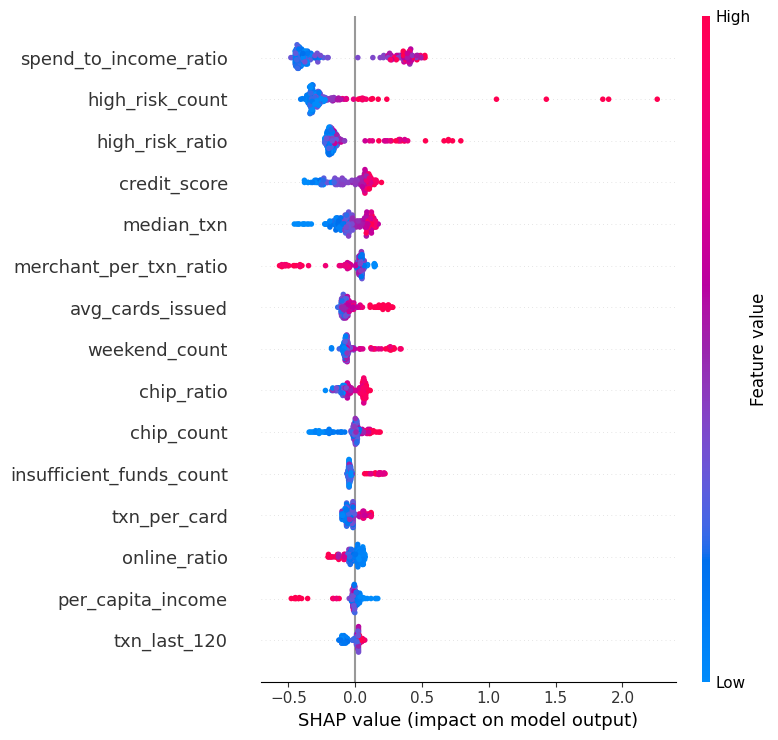

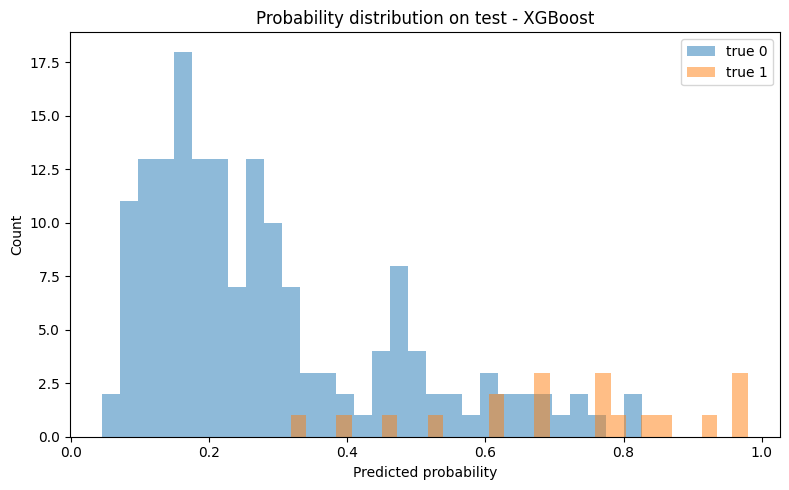

In [15]:
# 13. GIẢI THÍCH MÔ HÌNH TỐT NHẤT
# -----------------------------------------------------------------
if best_model_name == "XGBoost":
    print("Giải thích XGBoost bằng SHAP")
    imputer = best_model.named_steps["imputer"]
    xgb_core = best_model.named_steps["clf"]

    X_test_imputed = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )

    # Sample nhẹ để SHAP đỡ nặng nếu test lớn
    sample_n = min(1000, len(X_test_imputed))
    X_test_shap = X_test_imputed.sample(sample_n, random_state=RANDOM_STATE) if len(X_test_imputed) > sample_n else X_test_imputed

    explainer = shap.TreeExplainer(xgb_core)
    shap_values = explainer.shap_values(X_test_shap)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_shap, max_display=15)

elif best_model_name == "Random Forest":
    print("Giải thích Random Forest bằng feature importance")
    rf_core = best_model.named_steps["clf"]

    feature_importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf_core.feature_importances_
    }).sort_values("importance", ascending=False)

    display(feature_importance_df.head(20))

    top_plot = feature_importance_df.head(15).sort_values("importance")
    plt.figure(figsize=(10, 8))
    plt.barh(top_plot["feature"], top_plot["importance"])
    plt.title("Top 15 Feature Importance - Random Forest")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

else:
    print("Giải thích Logistic Regression bằng hệ số")
    lr_core = best_model.named_steps["clf"]

    coef_df = pd.DataFrame({
        "feature": X_train.columns,
        "coef": lr_core.coef_.ravel(),
        "abs_coef": np.abs(lr_core.coef_.ravel())
    }).sort_values("abs_coef", ascending=False)

    display(coef_df.head(20))

    top_plot = coef_df.head(15).sort_values("coef")
    plt.figure(figsize=(10, 8))
    plt.barh(top_plot["feature"], top_plot["coef"])
    plt.title("Top 15 Coefficients - Logistic Regression")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# Debug thêm: phân phối probability trên test
plt.figure(figsize=(8, 5))
plt.hist(test_prob[y_test == 0], bins=30, alpha=0.5, label="true 0")
plt.hist(test_prob[y_test == 1], bins=30, alpha=0.5, label="true 1")
plt.legend()
plt.title(f"Probability distribution on test - {best_model_name}")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
